In [2]:
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
# research_dir = "../"
# sys.path.insert(1, research_dir)

dict_keys(['name', 'width', 'height', 'frameRate', 'numFrames', 'durationSeconds', 'cameraFrames', 'trackPoints'])
3001
dict_keys(['position', 'rotation', 'coordinate', 'fovVertical'])
dict_keys(['latitude', 'longitude', 'altitude'])


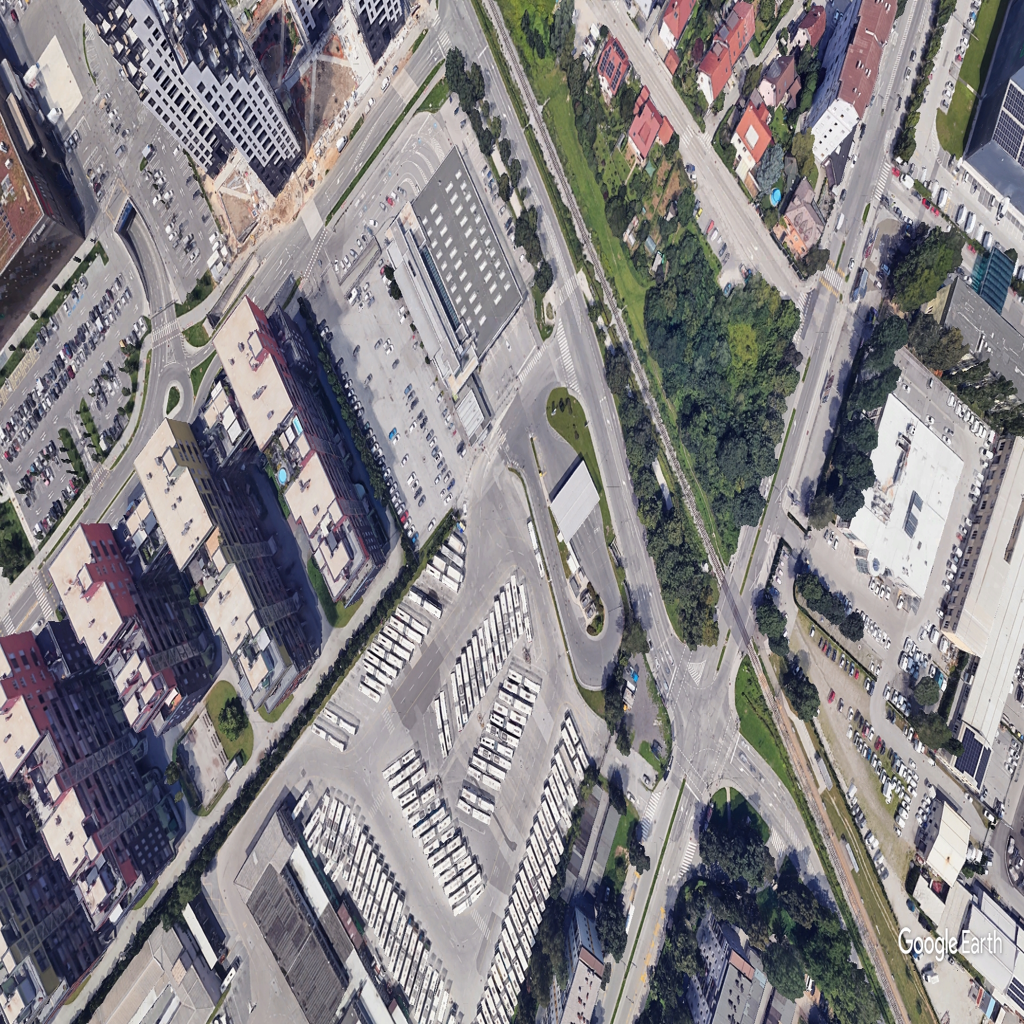

In [31]:
import torch
import json
from PIL import Image


trajectory_name = "Test1_Ljubljana_150m_80fov_90deg_3000"

root = f"/storage/datasets/AerialLoc/Drone2Sat/GES/{trajectory_name}/"
footage_dir = os.path.join(root, "footage")
metadata_path = os.path.join(root, "Test1_Ljubljana_150m_80fov_90deg_3000.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)
    
print(metadata.keys())
print(len(metadata["cameraFrames"]))
print(metadata["cameraFrames"][0].keys())
print(metadata["cameraFrames"][1000]["coordinate"].keys())

frame_ix = 100
frame = Image.open(os.path.join(footage_dir, f"{trajectory_name}_{frame_ix:04d}.jpeg"))
# frame.show()
frame = frame.resize((1024, 1024))
frame.show()


In [8]:
import torch
model = torch.hub.load("serizba/salad", "dinov2_salad")
model.eval()
model.cuda()

Using cache found in /home/grega/.cache/torch/hub/serizba_salad_main
Using cache found in /home/grega/.cache/torch/hub/facebookresearch_dinov2_main
/home/grega/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/grega/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/grega/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


VPRModel(
  (loss_fn): MultiSimilarityLoss(
    (distance): DotProductSimilarity()
    (reducer): MeanReducer()
  )
  (miner): MultiSimilarityMiner(
    (distance): CosineSimilarity()
  )
  (backbone): DINOv2(
    (model): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            

In [2]:
from research.data.dataset_FRI import FRIReferenceImages, FRIQueryImages
base_dir = "/storage/datasets/AerialLoc/Drone2Sat/FRISat/"
ref_database_root = os.path.join(base_dir, "arcgis/combined/256x256/2025/zoom19/")
qry_database_root = os.path.join("/storage/datasets/AerialLoc/Drone2Sat/FRISat/", "trajectories/FRI-110m-sunny/queries/")

resize_size = (322, 322)
ref_image_dataset = FRIReferenceImages(root=ref_database_root, resize=resize_size)
# ref_image_dataloader = DataLoader(ref_image_dataset, batch_size=vlad_fit_batchsize, shuffle=False)
qry_image_dataset = FRIQueryImages(root=qry_database_root, resize=resize_size)

ModuleNotFoundError: No module named 'utils'

In [30]:
x = ref_image_dataset[0]["image"]
x = x.unsqueeze(0).cuda()
with torch.no_grad():
    x = model(x)
    print(x.shape)
x

torch.Size([1, 8448])


tensor([[-0.0034, -0.0011, -0.0054,  ...,  0.0060,  0.0058, -0.0094]],
       device='cuda:0')